In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

In [2]:
df1 = pd.read_csv('cells_concat_raw_1.csv', index_col=0)
df2 = pd.read_csv('cells_concat_raw_2.csv', index_col=0)
df = pd.concat([df1, df2], ignore_index=True)

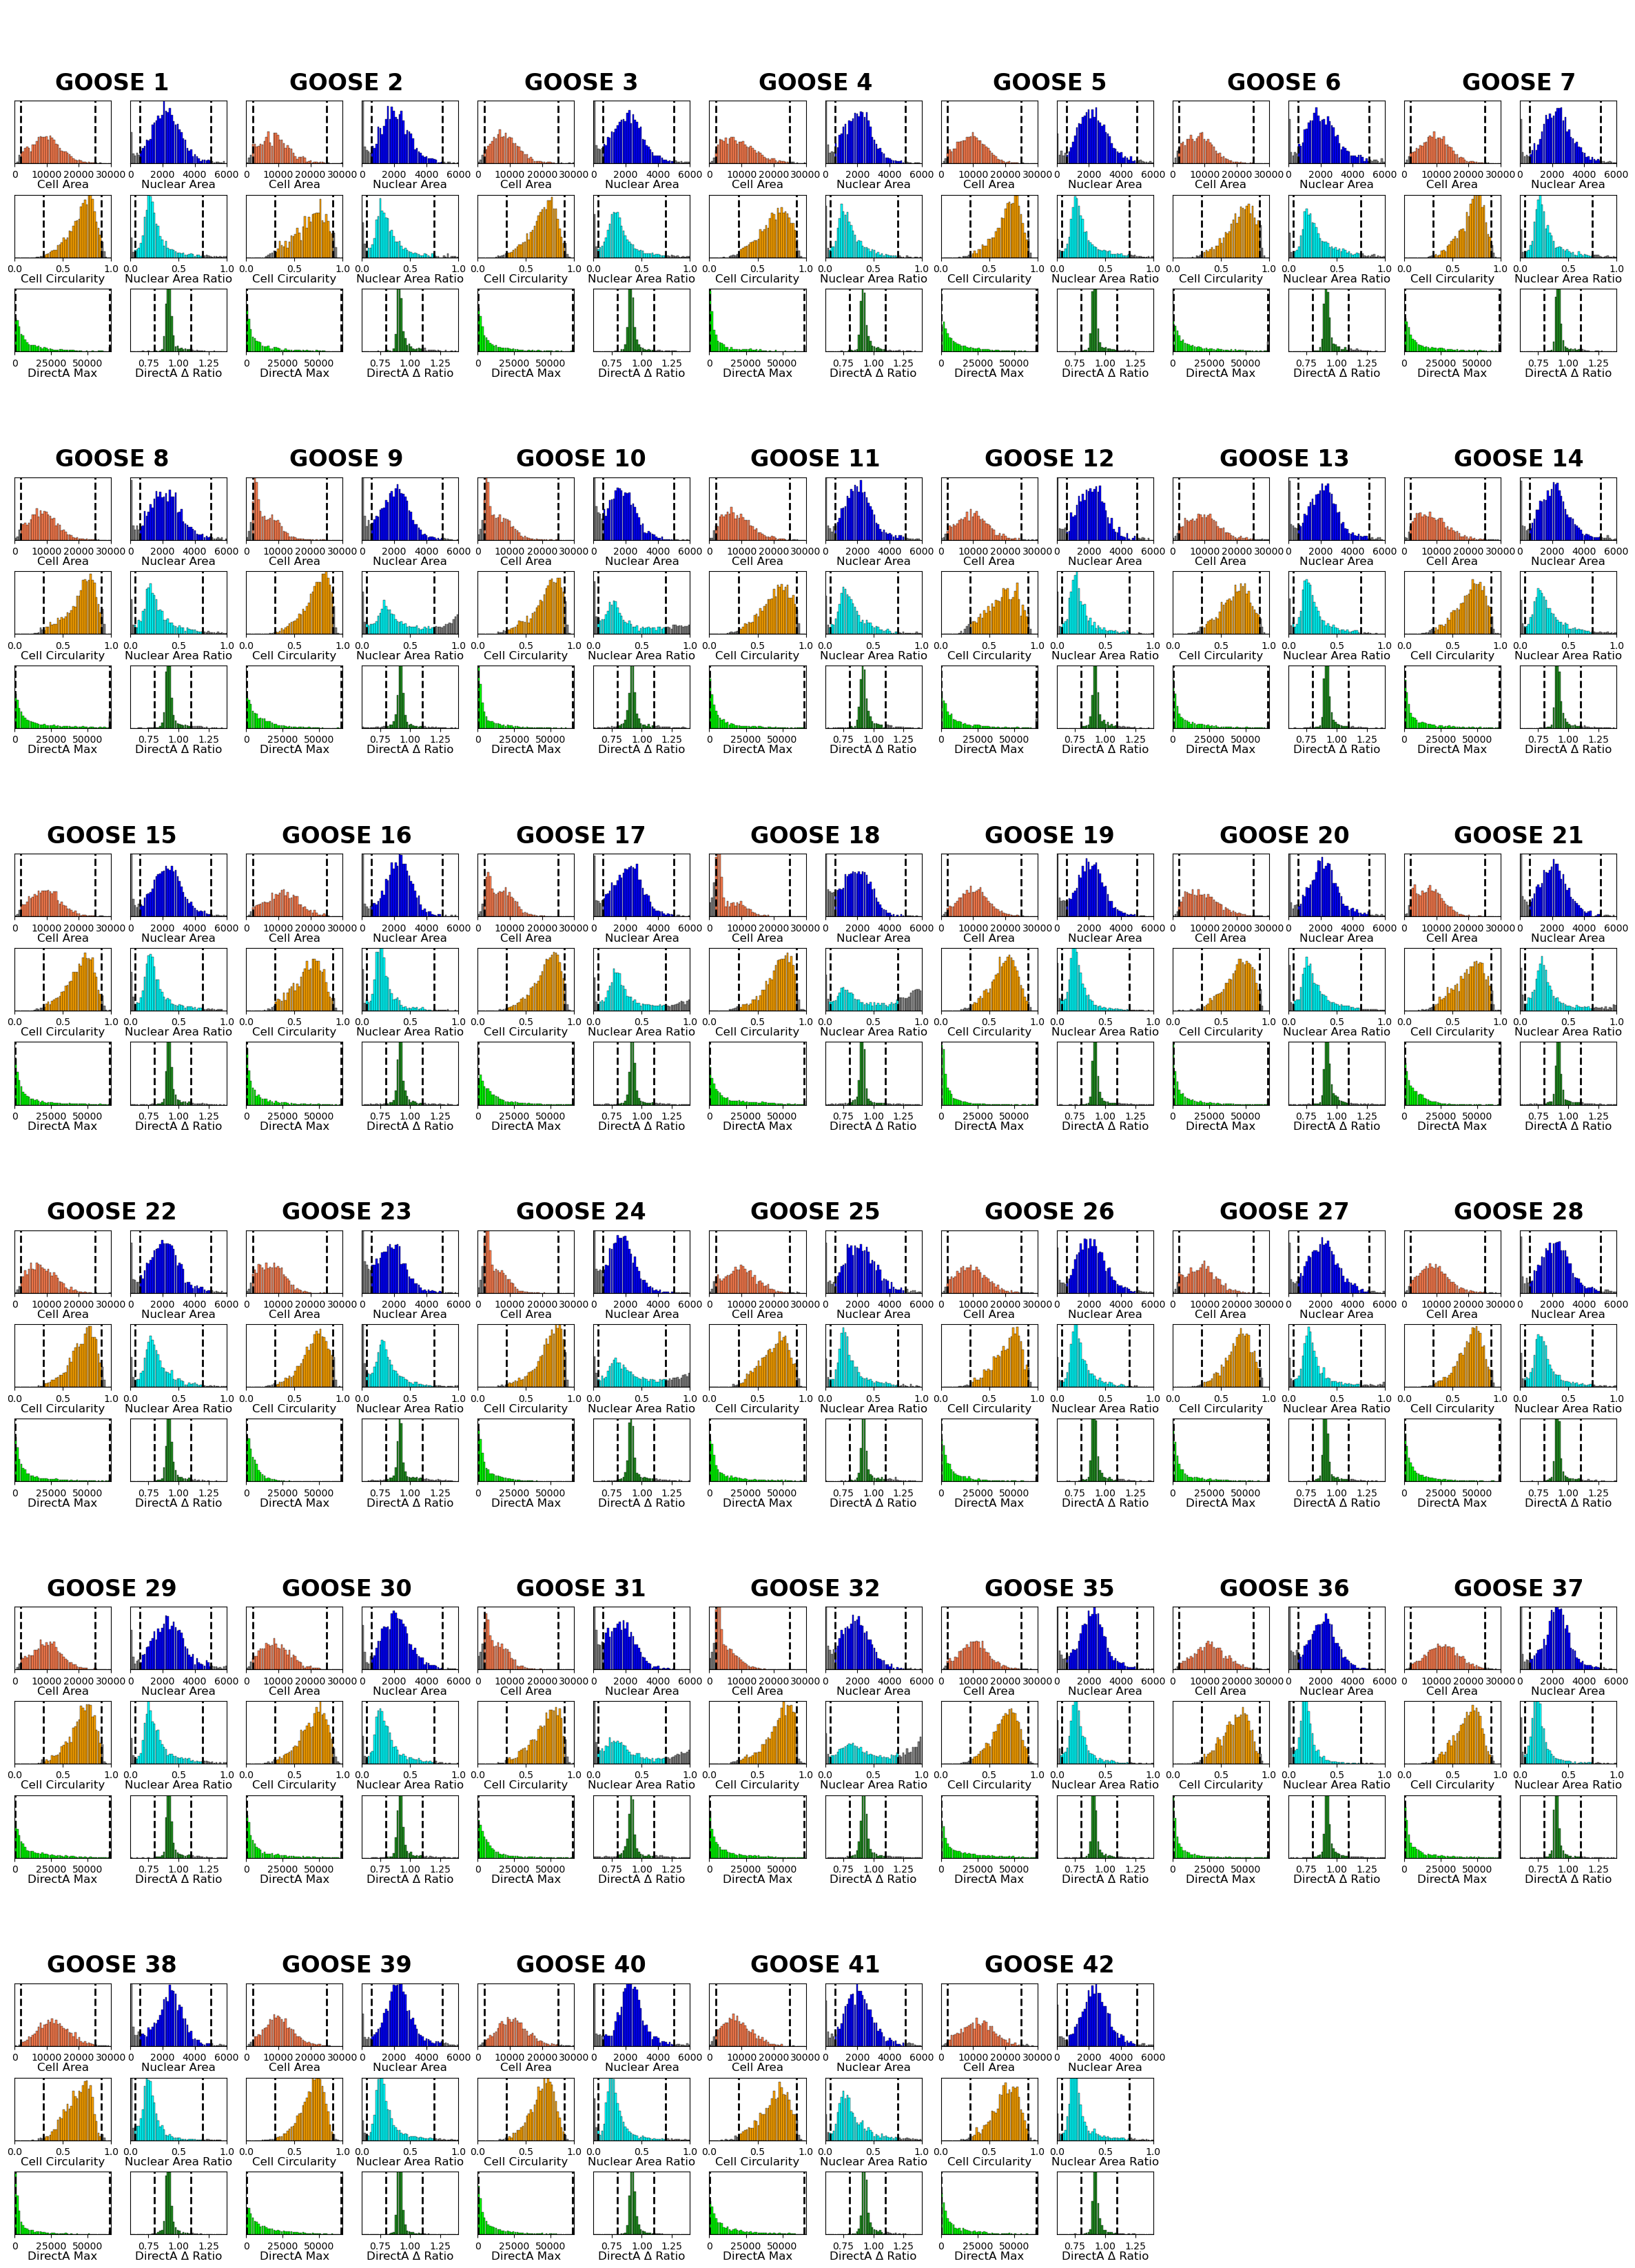

In [3]:
# Create a large figure with all constructs
constructs = sorted(df['construct'].unique())
n_constructs = len(constructs)

# Calculate grid: each construct gets 3 rows (for 3x2 mini plots) + 1 label row
# Let's do 4 constructs per "row block"
constructs_per_row = 7
n_row_blocks = math.ceil(n_constructs / constructs_per_row)

# Each construct needs 4 rows: 1 for label + 3 for the 3x2 grid of histograms
rows_per_construct_block = 4
total_rows = n_row_blocks * rows_per_construct_block

fig = plt.figure(figsize=(30, 7 * n_row_blocks))

# Define the 6 filter parameters
filters = [
    {'column': 'area_cell_original', 'bins': 50, 'xlim': (0, 30000), 'ylim': (0, .0002),
     'filter_range': (2000, 25000), 'color': 'coral', 'xlabel': 'Cell Area', 'normalize': True},
    {'column': 'area_nuc', 'bins': 50, 'xlim': (0, 6000), 'ylim': (0, .0005),
     'filter_range': (600, 5000), 'color': 'blue', 'xlabel': 'Nuclear Area', 'normalize': True},
    {'column': 'circ_cell_original', 'bins': 50, 'xlim': (0, 1), 'ylim': (0, 3.5),
     'filter_range': (.3, .9), 'color': 'orange', 'xlabel': 'Cell Circularity', 'normalize': True},
    {'column': 'nuc_area_ratio', 'bins': 50, 'xlim': (0, 1), 'ylim': (0, 5),
     'filter_range': (0.05, .75), 'color': 'cyan', 'xlabel': 'Nuclear Area Ratio', 'normalize': True},
    {'column': 'directA_cell_max', 'bins': 50, 'xlim': (0, 66000), 'ylim': (0, .0002),
     'filter_range': (400, 65000), 'color': 'lime', 'xlabel': 'DirectA Max', 'normalize': True},
    {'column': 'directA_cell_delta_ratio', 'bins': 50, 'xlim': (.6, 1.4), 'ylim': (0, 12),
     'filter_range': (0.8, 1.1), 'color': 'forestgreen', 'xlabel': 'DirectA Δ Ratio', 'normalize': True},
]

# Loop through each construct
for construct_idx, construct in enumerate(constructs):
    # Calculate which row block this construct belongs to
    row_block = construct_idx // constructs_per_row
    col_in_block = construct_idx % constructs_per_row
    
    # Starting row for this construct (each block is 4 rows tall)
    start_row = row_block * rows_per_construct_block
    
    # Add construct label at the top
    ax_label = plt.subplot2grid((total_rows, constructs_per_row), 
                                (start_row, col_in_block), fig=fig)
    # Move title closer to plots by adjusting vertical alignment to bottom
    ax_label.text(0.5, -0.4, f'GOOSE {int(construct)}', 
                  ha='center', va='bottom', fontsize=24, fontweight='bold')
    ax_label.axis('off')
    
    # Get data for this construct
    construct_data = df[df['construct'] == construct]
    
    # Loop through each filter (6 mini subplots in 3x2 grid)
    for filter_idx, filter_params in enumerate(filters):
        mini_row = filter_idx // 2  # 0, 0, 1, 1, 2, 2
        mini_col = filter_idx % 2   # 0, 1, 0, 1, 0, 1
        
        # Create subplot in a finer grid (triple the columns for spacing between constructs)
        # This adds padding columns between each construct's pair of mini-plots
        ax = plt.subplot2grid((total_rows, constructs_per_row * 2), 
                             (start_row + 1 + mini_row, col_in_block * 2 + mini_col), 
                             fig=fig)
        
        # Get column data
        column = filter_params['column']
        data = construct_data[column].dropna()
        
        if len(data) > 0:
            # Calculate histogram
            bins = filter_params['bins']
            xlim = filter_params['xlim']
            
            if xlim is not None:
                bin_edges = np.linspace(xlim[0], xlim[1], bins + 1)
            else:
                bin_edges = np.linspace(data.min(), data.max(), bins + 1)
            
            counts, edges = np.histogram(data, bins=bin_edges, 
                                        density=filter_params['normalize'])
            bin_centers = (edges[:-1] + edges[1:]) / 2
            bin_width = edges[1] - edges[0]
            
            # Determine colors
            filter_range = filter_params.get('filter_range')
            if filter_range is not None:
                left, right = filter_range
                bar_colors = [filter_params['color'] if left <= bc <= right else 'grey' 
                            for bc in bin_centers]
            else:
                bar_colors = [filter_params['color']] * len(counts)
            
            # Plot bars
            ax.bar(bin_centers, counts, width=bin_width * 0.9, 
                  color=bar_colors, edgecolor='black', linewidth=0.3)
            
            # Add dashed lines
            if filter_range is not None:
                left, right = filter_range
                ax.axvline(left, color='black', linestyle='--', linewidth=2, alpha=1)
                ax.axvline(right, color='black', linestyle='--', linewidth=2, alpha=1)
            
            # Set limits
            if xlim is not None:
                ax.set_xlim(xlim)
            if filter_params['ylim'] is not None:
                ax.set_ylim(filter_params['ylim'])
            
            # Add labels
            ax.set_xlabel(filter_params['xlabel'], fontsize=12, labelpad=0)
            ax.set_ylabel('')
            # Remove y-axis tick marks and labels
            ax.set_yticks([])
            ax.tick_params(labelsize=10)
            ax.grid(True, linestyle=':', alpha=0.3, axis='y')
            
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', 
                   transform=ax.transAxes, fontsize=8)
            ax.set_xlim(filter_params['xlim'])
            ax.set_ylim(filter_params['ylim'])
            # Remove y-axis tick marks and labels for empty plots too
            ax.set_yticks([])

# Adjust spacing: reduce vertical space between row blocks, keep horizontal spacing
plt.subplots_adjust(hspace=.5)
#plt.subplots_adjust(wspace=0, hspace = .1)
plt.savefig('Figure_graphs/FigSI/Figure_SI_FilterDisplays.svg', bbox_inches='tight')

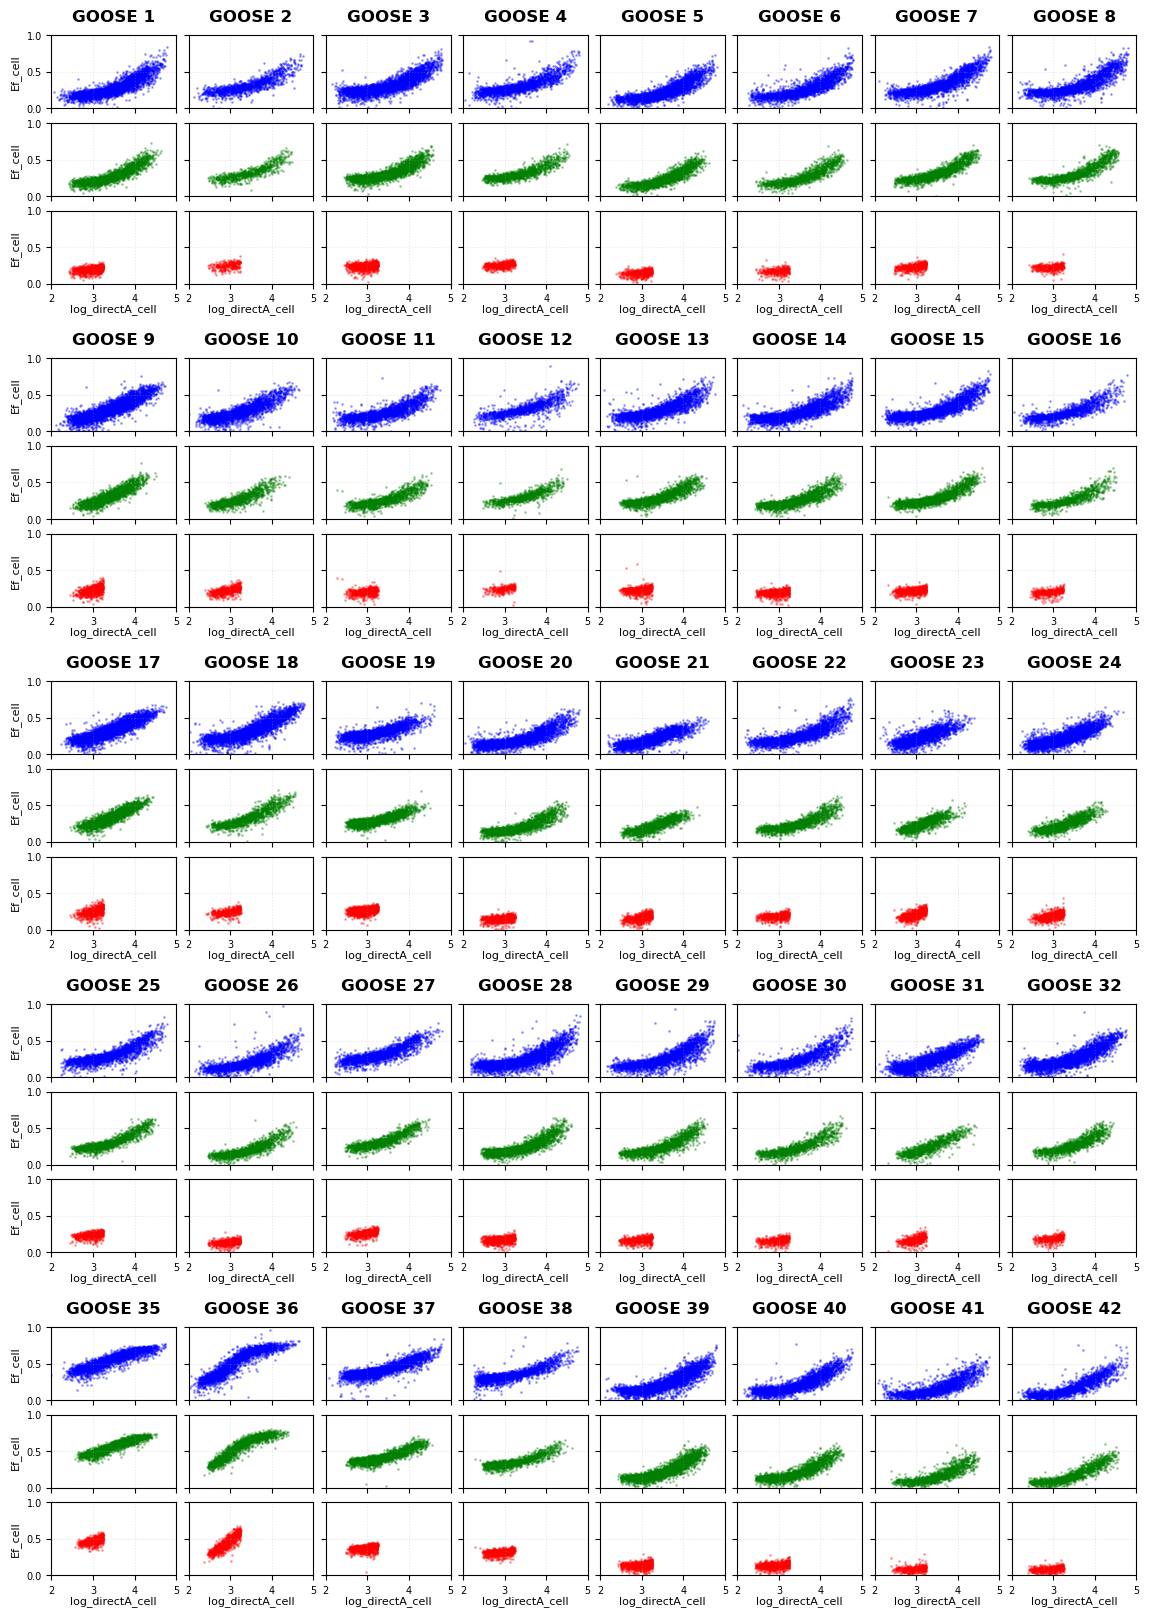

In [4]:
from matplotlib.gridspec import GridSpec

# Create a large figure with all constructs showing filtering progression
constructs = sorted(df['construct'].unique())
n_constructs = len(constructs)

# Calculate grid dimensions for construct layout
constructs_per_row = 8
n_row_blocks = math.ceil(n_constructs / constructs_per_row)

# Each construct needs 3 rows for the 3 filtering stages
rows_per_construct = 3

# Create figure
fig = plt.figure(figsize=(14, 4 * n_row_blocks))

# Create outer GridSpec for construct groups (with large spacing between constructs)
outer_gs = GridSpec(n_row_blocks, constructs_per_row, figure=fig, 
                    hspace=0.3, wspace=0.1)  # Spacing BETWEEN constructs

# Loop through each construct
for construct_idx, construct in enumerate(constructs):
    # Calculate position in overall grid
    row_block = construct_idx // constructs_per_row
    col_in_block = construct_idx % constructs_per_row
    
    # Get data for this construct
    construct_data = df[df['construct'] == construct].copy()
    
    # Create inner GridSpec for this construct's 3 subplots (with minimal spacing)
    inner_gs = outer_gs[row_block, col_in_block].subgridspec(3, 1, 
                                                              hspace=0.2)  # Minimal spacing WITHIN construct
    
    # --- SUBPLOT 1: Unfiltered data ---
    ax1 = fig.add_subplot(inner_gs[0])
    
    if len(construct_data) > 0:
        ax1.scatter(construct_data['log_directA_cell'], construct_data['Ef_cell'], 
                   s=1, alpha=0.3, c='blue')
        ax1.set_xlim(2, 5)
        ax1.set_ylim(0, 1)
    else:
        ax1.text(0.5, 0.5, 'No data', ha='center', va='center', 
                transform=ax1.transAxes, fontsize=10)
        ax1.set_xlim(2, 5)
        ax1.set_ylim(0, 1)
    
    # Add construct title only on first subplot
    ax1.set_title(f'GOOSE {int(construct)}', 
                 fontsize=12, fontweight='bold', pad=10)
    # Only show y-axis label for first column
    if col_in_block == 0:
        ax1.set_ylabel('Ef_cell', fontsize=8)
    if col_in_block != 0:
        ax1.set_yticklabels([])
    ax1.tick_params(labelsize=7, labelbottom=False)  # Remove x-axis labels
    ax1.grid(True, linestyle=':', alpha=0.3)
    
    # --- Apply Filter 1 ---
    filtered_data = construct_data[
        (construct_data['directA_cell_max'] >= 400) &
        (construct_data['directA_cell_max'] <= 65000) &
        (construct_data['directA_cell_delta_ratio'] > 0.8) &
        (construct_data['directA_cell_delta_ratio'] < 1.1) &
        (construct_data['circ_cell_original'] < 0.8) &
        (construct_data['circ_cell_original'] > 0.3) &
        (construct_data['nuc_area_ratio'] < 0.75) &
        (construct_data['nuc_area_ratio'] > 0.05) &
        (construct_data['A_cell_corr'] > 0) &
        (construct_data['area_cell'] > 2000) &
        (construct_data['area_cell'] < 25000) &
        (construct_data['area_nuc'] < 5000) &
        (construct_data['area_nuc'] > 600)
    ].copy()
    
    # --- SUBPLOT 2: Filter 1 applied ---
    ax2 = fig.add_subplot(inner_gs[1], sharex=ax1)
    
    if len(filtered_data) > 0:
        ax2.scatter(filtered_data['log_directA_cell'], filtered_data['Ef_cell'], 
                   s=1, alpha=0.3, c='green')
        ax2.set_xlim(2, 5)
        ax2.set_ylim(0, 1)
    else:
        ax2.text(0.5, 0.5, 'No data', ha='center', va='center', 
                transform=ax2.transAxes, fontsize=10)
        ax2.set_xlim(2, 5)
        ax2.set_ylim(0, 1)
    
    # Only show y-axis label for first column
    if col_in_block == 0:
        ax2.set_ylabel('Ef_cell', fontsize=8)
    if col_in_block != 0:
        ax2.set_yticklabels([])
    ax2.tick_params(labelsize=7, labelbottom=False)  # Remove x-axis labels
    ax2.grid(True, linestyle=':', alpha=0.3)
    
    # --- Apply Filter 2 ---
    filtered_data2 = filtered_data[
        (filtered_data['log_directA_cell'] < 3.25) &
        (filtered_data['log_directA_cell'] > 2)
    ].copy()
    
    # --- SUBPLOT 3: Filter 2 applied ---
    ax3 = fig.add_subplot(inner_gs[2], sharex=ax1)
    
    if len(filtered_data2) > 0:
        ax3.scatter(filtered_data2['log_directA_cell'], filtered_data2['Ef_cell'], 
                   s=1, alpha=0.3, c='red')
        ax3.set_xlim(2, 5)
        ax3.set_ylim(0, 1)
    else:
        ax3.text(0.5, 0.5, 'No data', ha='center', va='center', 
                transform=ax3.transAxes, fontsize=10)
        ax3.set_xlim(2, 5)
        ax3.set_ylim(0, 1)
    
    ax3.set_xlabel('log_directA_cell', fontsize=8, labelpad=0)
    # Only show y-axis label for first column
    if col_in_block == 0:
        ax3.set_ylabel('Ef_cell', fontsize=8)
    if col_in_block != 0:
        ax3.set_yticklabels([])
    ax3.tick_params(labelsize=7)  # Keep x-axis labels for bottom plot
    ax3.grid(True, linestyle=':', alpha=0.3)

plt.savefig('Figure_graphs/FigSI/ConcentrationFilters.svg', bbox_inches='tight')
plt.show()